# Baseline DenseNet

## Objective
Establish a lower-bound baseline for DenseNet-121 trained from scratch with a direct
linear head, no class weighting, and no regularisation. All subsequent experiments
build on this reference point.
 
## Architecture
 
| Component | 01. Baseline |
|---|---|
| Pretrained | False |
| Frozen backbone | False |
| Hidden dim | 0 (direct linear head) |
| Dropout | 0.0 |
| Pos weight | None |
| Optimiser | AdamW |
| Weight decay | 1e-4 |
| LR | 1e-3 |
| Epochs | 30 |
 
## Hypothesis
Training from random initialisation with no class-balancing establishes the performance
floor. The majority class (nevus) will dominate and melanoma recall will be poor, but
this gives a clean reference point for all subsequent iterations.

## Import libraries, set seed, and choose device

In [ ]:
import sys
import random
from pathlib import Path
 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
 
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))
 
from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.densenet import get_densenet121
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
 
import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning


## Load and split data

In [ ]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


## Model Definition

In [ ]:
model = get_densenet121(
    num_classes=1,
    pretrained=False,
    freeze_backbone=False,
    dropout=0.0,
    hidden_dim=0,
).to(device)
 
criterion = nn.BCEWithLogitsLoss()
 
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
 
num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)
 
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print('Pretrained: False | Frozen: False | Dropout: 0.0 | Hidden dim: 0 | Pos weight: None')

## Training Loop

In [ ]:
best_val_auc = 0.0
train_history, val_history = [], []
 
for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics   = validate_one_epoch(model, val_loader, criterion, device)
 
    scheduler.step()
 
    train_history.append(train_metrics)
    val_history.append(val_metrics)
 
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")
 
    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/densenet121_baseline_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/20] | Train Loss: 0.3203, Train Acc: 0.8777 | Val Loss: 0.2836, Val Acc: 0.8844


Epoch [2/20] | Train Loss: 0.2642, Train Acc: 0.8930 | Val Loss: 0.2795, Val Acc: 0.8859


Epoch [3/20] | Train Loss: 0.2554, Train Acc: 0.8948 | Val Loss: 0.2780, Val Acc: 0.8849


Epoch [4/20] | Train Loss: 0.2467, Train Acc: 0.8960 | Val Loss: 0.2631, Val Acc: 0.8883


Epoch [5/20] | Train Loss: 0.2450, Train Acc: 0.8978 | Val Loss: 0.2665, Val Acc: 0.8883


...

Epoch [16/20] | Train Loss: 0.2093, Train Acc: 0.9064 | Val Loss: 0.2826, Val Acc: 0.8790


Epoch [17/20] | Train Loss: 0.2025, Train Acc: 0.9134 | Val Loss: 0.2560, Val Acc: 0.8888


Epoch [18/20] | Train Loss: 0.2013, Train Acc: 0.9101 | Val Loss: 0.2559, Val Acc: 0.8962


Epoch [19/20] | Train Loss: 0.1981, Train Acc: 0.9170 | Val Loss: 0.2666, Val Acc: 0.8982


Epoch [20/20] | Train Loss: 0.1893, Train Acc: 0.9189 | Val Loss: 0.2556, Val Acc: 0.8953


## Plot Train and Validation Curves

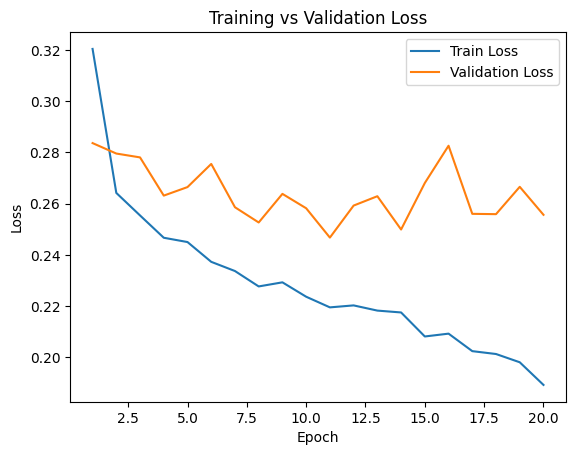

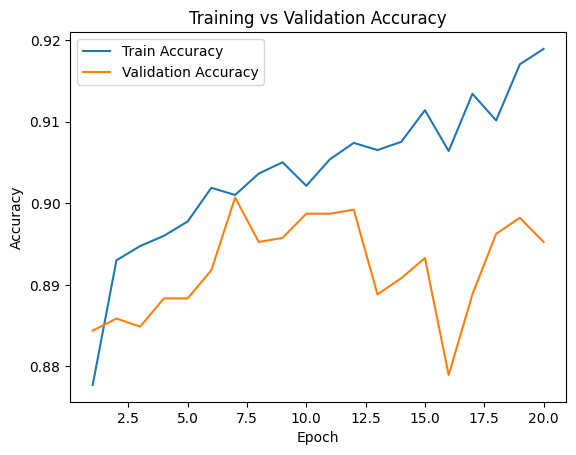

In [ ]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [ ]:
model.load_state_dict(torch.load(str(ROOT / 'models/densenet121_baseline_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

## Test Set Evaluation

In [ ]:
evaluate_model(model, test_loader, device, threshold=best_threshold)